In [ ]:
#Names: Trevor Henderson, Gabriel Machorro, Priyanshu Rathor
#dataset: https://www.kaggle.com/datasets/aslanahmedov/predict-term-deposit

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [ ]:
df=pd.read_csv('Assignment-2_Data.csv')
print(df.head())

     Id    age           job  marital  education default  balance housing  \
0  1001  999.0    management  married   tertiary      no   2143.0     yes   
1  1002   44.0    technician   single  secondary      no     29.0     yes   
2  1003   33.0  entrepreneur  married  secondary      no      2.0     yes   
3  1004   47.0   blue-collar  married    unknown      no   1506.0     yes   
4  1005   33.0       unknown   single    unknown      no      1.0      no   

  loan  contact  day month  duration  campaign  pdays  previous poutcome   y  
0   no  unknown    5   may       261         1     -1         0  unknown  no  
1   no  unknown    5   may       151         1     -1         0  unknown  no  
2  yes  unknown    5   may        76         1     -1         0  unknown  no  
3   no  unknown    5   may        92         1     -1         0  unknown  no  
4   no  unknown    5   may       198         1     -1         0  unknown  no  


In [ ]:

# replace age value 999 with the median age
median_age = df.loc[df["age"] != 999, "age"].median()
df["age"] = df["age"].replace(999, median_age)

# convert housing from yes/no to 1/0
df["housing"] = df["housing"].map({"yes": 1, "no": 0})

# create contacted before from pdays for clearer output
df["contacted_before"] = np.where(df["pdays"] == -1, 0, 1)

# change target to numeric for algo to understand
df["y"] = df["y"].map({"yes": 1, "no": 0})

df.head()

,Id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,contacted_before
0,1001,39.0,management,married,tertiary,no,2143.0,1,no,unknown,5,may,261,1,-1,0,unknown,0,0
1,1002,44.0,technician,single,secondary,no,29.0,1,no,unknown,5,may,151,1,-1,0,unknown,0,0
2,1003,33.0,entrepreneur,married,secondary,no,2.0,1,yes,unknown,5,may,76,1,-1,0,unknown,0,0
3,1004,47.0,blue-collar,married,unknown,no,1506.0,1,no,unknown,5,may,92,1,-1,0,unknown,0,0
4,1005,33.0,unknown,single,unknown,no,1.0,0,no,unknown,5,may,198,1,-1,0,unknown,0,0


In [ ]:
# split dataset in features and target variable
x_data = df[['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'housing', 'contacted_before']]
y_data = df['y']

In [ ]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.3, random_state=1)

In [ ]:
# Create Decision Tree classifier object
dt_model = DecisionTreeClassifier(max_depth=5)

# Train Decision Tree Classifer
dt_model2 = dt_model.fit(X_train, y_train)

# Predict the response for test dataset
y_pred = dt_model2.predict(X_test)

In [ ]:
# Model Accuracy
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))

Accuracy: 0.8919197876732528


In [ ]:
# Measure precision, recall, and f1 score.
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print(f"The precision of the model is {precision:.2f}.")
print(f"The recall of the model is {recall:.2f}.")
print(f"The F1-score of the model is {f1:.2f}.")

              precision    recall  f1-score   support

           0       0.92      0.96      0.94     12013
           1       0.54      0.38      0.45      1551

    accuracy                           0.89     13564
   macro avg       0.73      0.67      0.69     13564
weighted avg       0.88      0.89      0.88     13564

The precision of the model is 0.54.
The recall of the model is 0.38.
The F1-score of the model is 0.45.


In [ ]:
# Prepare a provision for a new data entry and its prediction of an outcome.
# model inputs to try to see what the model decides based on specific values
def predict_subscription():
    while True:
        try:
            age = float(input("Enter age: "))
            balance = float(input("Enter balance: "))
            day = int(input("Enter day: "))
            duration = int(input("Enter duration: "))
            campaign = int(input("Enter campaign: "))
            previous = int(input("Enter previous: "))
            housing = int(input("Enter housing (1 for yes, 0 for no): "))
            pdays = int(input("Enter pdays: "))

            if any(val < 0 for val in [age, balance, day, duration, campaign, previous]):
                print("Error: Please enter non-negative values.")
                continue

            if age == 999:
                age = median_age

            contacted_before = 0 if pdays == -1 else 1

            new_customer_data = pd.DataFrame(
                [[age, balance, day, duration, campaign, previous, housing, contacted_before]],
                columns=['age', 'balance', 'day', 'duration', 'campaign', 'previous', 'housing', 'contacted_before']
            )

            prediction = dt_model2.predict(new_customer_data)

            if prediction[0] == 1:
                print("Prediction: Customer will subscribe.")
            else:
                print("Prediction: Customer will not subscribe.")
            break

        except ValueError:
            print("Error: Please enter valid numeric values.")

predict_subscription()

Enter age: 4
Enter balance: 5
Enter day: 5
Enter duration: 5
Enter campaign: 5
Enter previous: 5432
Enter housing (1 for yes, 0 for no): 1
Enter pdays: 1
Prediction: Customer will not subscribe.


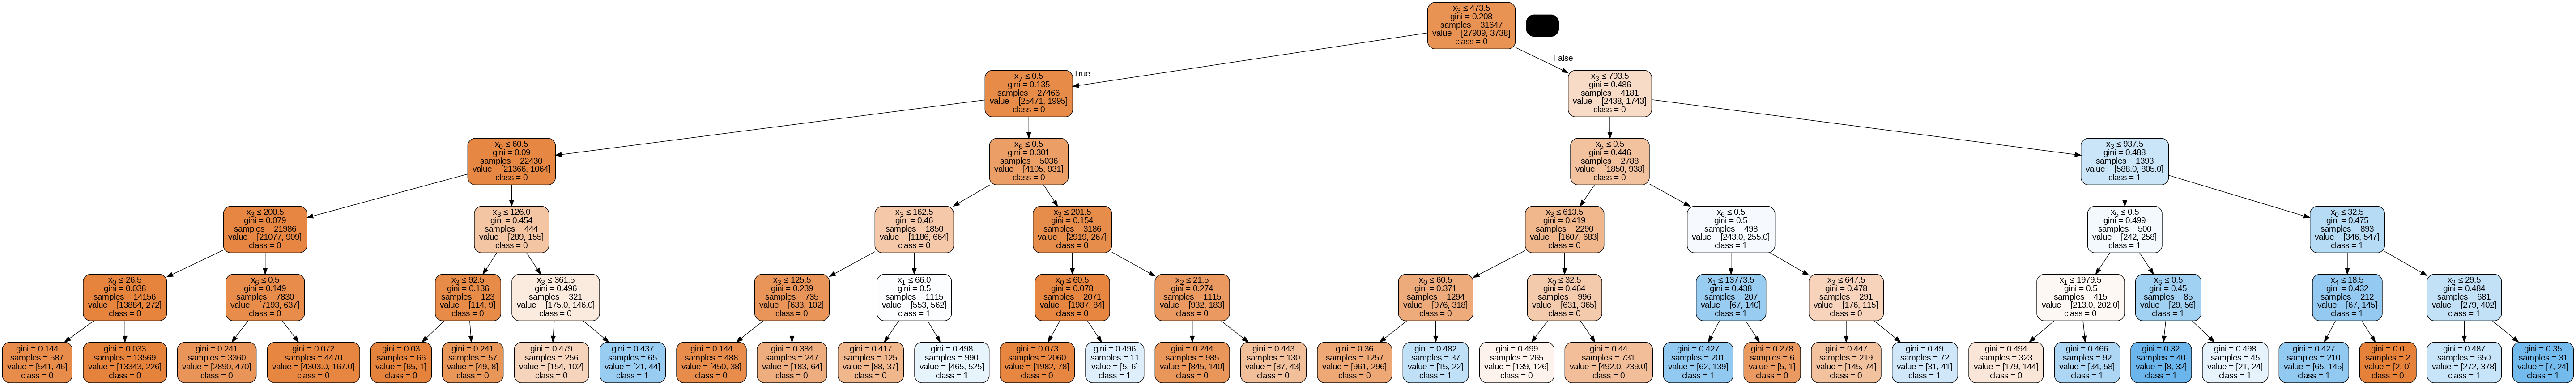

In [ ]:
#make the graph to visualize the decision tree model in a simple way
from sklearn.tree import export_graphviz
from six import StringIO
from IPython.display import Image
import pydotplus

dot_data = StringIO()
export_graphviz(dt_model2, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True, class_names=['0', '1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('bank_tree.png')
Image(graph.create_png())

#3)This project built a Decision Tree model to predict whether a bank customer would subscribe to a term deposit using factors like age, account balance, and contact history. The data was cleaned beforehand to handle missing values and convert text fields into numbers the model could process. The model performed well overall, though it struggled to catch every actual subscriber, which is typical when one outcome is much rarer than the other in the dataset. In the real world, a model like this could help banks prioritize which customers to contact, saving time and resources by focusing outreach on those most likely to subscribe.

#4)The root node shows a splitting rule of x₂ ≤ 479.5, meaning the tree splits based on whether a customer's balance is 479.5 or below. The gini value of 0.308 indicates the node is moderately impure, meaning there is a mix of both classes present. Out of the 3,049 total training samples that pass through this node, 2,722 belong to class 0 (will not subscribe) and 327 belong to class 1 (will subscribe), shown by the value field. Since class 0 holds the majority, the node's current prediction is that the customer will not subscribe, and the tree continues splitting from here to make more refined predictions.